In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importing the datasets
df = pd.read_csv('advertising.csv')

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.info() # Checking the datatype of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
# Checking that is there any null value present in the dataset or not ?
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

As there is no null value then we have a clean data , now only we have to check the outliers and if there are outliers then we have to remove them.....

In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.shape

(200, 4)

In [8]:
df.ndim

2

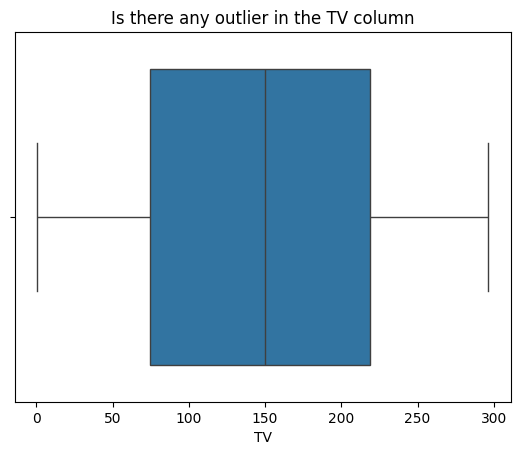

In [9]:
sns.boxplot(x = 'TV', data = df)
plt.title("Is there any outlier in the TV column")
plt.show()

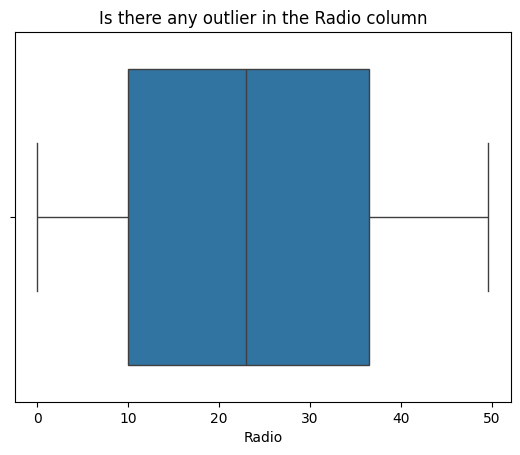

In [10]:
sns.boxplot(x = 'Radio', data = df)
plt.title("Is there any outlier in the Radio column")
plt.show()

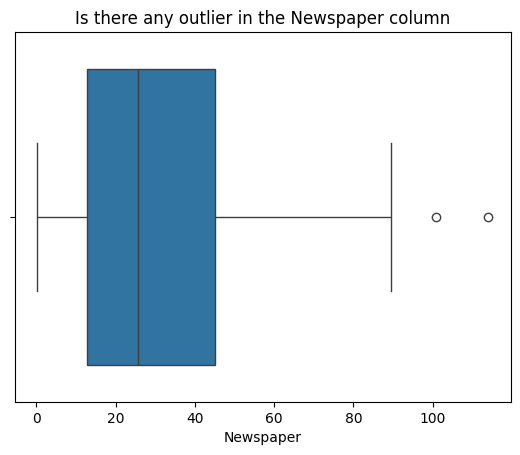

In [11]:
sns.boxplot(x = 'Newspaper', data = df)
plt.title("Is there any outlier in the Newspaper column")
plt.show()

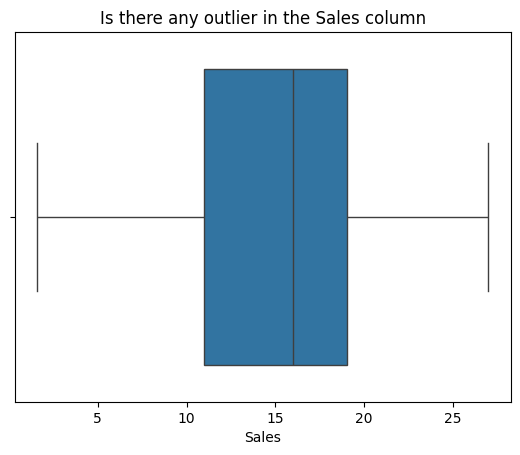

In [12]:
sns.boxplot(x = 'Sales', data = df)
plt.title("Is there any outlier in the Sales column")
plt.show()

In [13]:
# Reving the outliers from the News_paper columns
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [14]:
Q1 = df['Newspaper'].quantile(0.25) # Removing the outlier
Q3 = df['Newspaper'].quantile(0.75)
IQR = Q3 - Q1
print(f"The Inter quatile range is: {IQR}")
lowerbound = Q1 - 1.5 * IQR
upperbound = Q3 + 1.5 * IQR
print(f'{lowerbound} - {upperbound}')
outlier = df[(df['Newspaper'] < lowerbound) | (df['Newspaper'] > upperbound)]
outlier

The Inter quatile range is: 32.35
-35.775000000000006 - 93.625


,TV,Radio,Newspaper,Sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


In [15]:
outlier.index

Index([16, 101], dtype='int64')

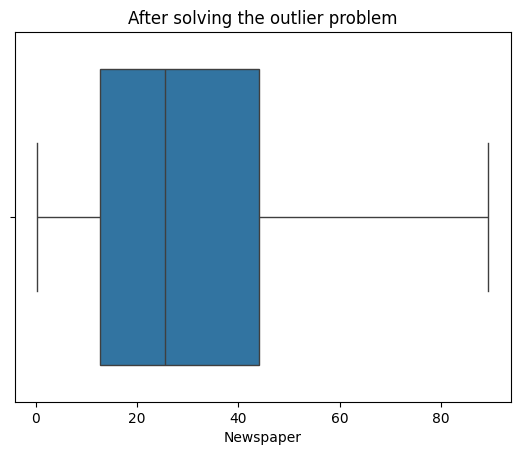

In [16]:
df.drop(outlier.index, inplace=True)
sns.boxplot(x = 'Newspaper', data = df)
plt.title('After solving the outlier problem')
plt.show()

In [17]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [18]:
df['TV'].value_counts()

TV
240.1    2
184.9    2
237.4    2
109.8    2
199.8    2
        ..
216.8    1
199.1    1
26.8     1
129.4    1
232.1    1
Name: count, Length: 188, dtype: int64

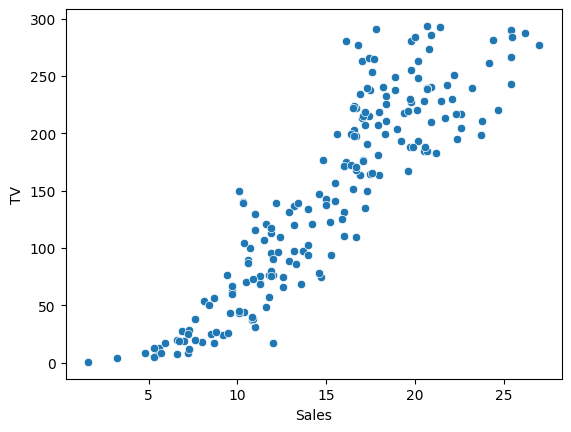

In [19]:
sns.scatterplot(x = 'Sales', y = 'TV', data = df)
plt.show()

In [20]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.051978,0.049771,0.899974
Radio,0.051978,1.000000,0.346364,0.348566
Newspaper,0.049771,0.346364,1.000000,0.151764
Sales,0.899974,0.348566,0.151764,1.000000


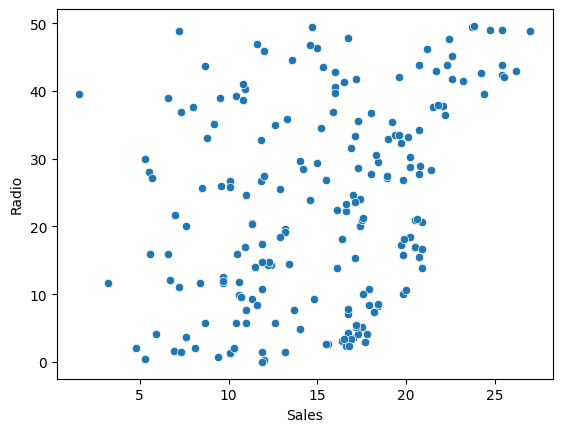

In [21]:
sns.scatterplot(x = 'Sales', y = 'Radio', data = df)
plt.show()

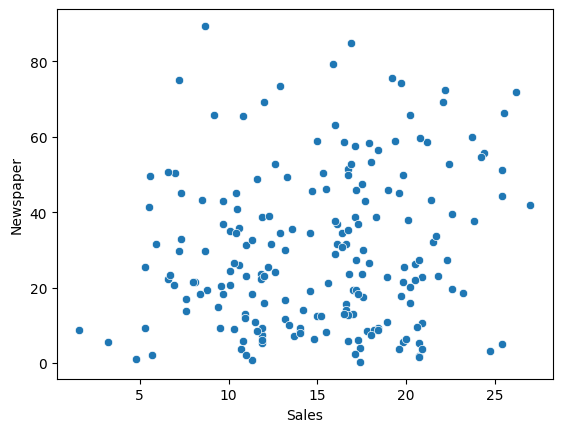

In [22]:
sns.scatterplot(x = 'Sales', y = 'Newspaper', data = df)
plt.show()

In [23]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [24]:
df.shape

(198, 4)

In [25]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.051978,0.049771,0.899974
Radio,0.051978,1.000000,0.346364,0.348566
Newspaper,0.049771,0.346364,1.000000,0.151764
Sales,0.899974,0.348566,0.151764,1.000000


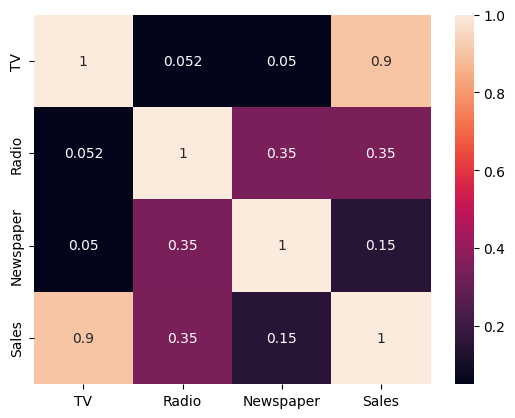

In [26]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [27]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [28]:
# # There is no categorical column in this dataset fo that resion we will go with the features scalling
l = [['TV','Radio','Newspaper','Sales']]
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
for i in l:
    df[i] = mm.fit_transform(df[i])

In [29]:
df.head()

,TV,Radio,Newspaper,Sales
0,0.783202,0.762097,0.773288,0.807087
1,0.149539,0.792339,0.502806,0.346457
2,0.056333,0.925403,0.774411,0.409449
3,0.514851,0.832661,0.653199,0.586614
4,0.614886,0.217742,0.652076,0.641732


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         198 non-null    float64
 1   Radio      198 non-null    float64
 2   Newspaper  198 non-null    float64
 3   Sales      198 non-null    float64
dtypes: float64(4)
memory usage: 7.7 KB


In [31]:
# Now going with the feature selection
x = df[['TV','Radio','Newspaper']]
y = df['Sales']
from sklearn.feature_selection import SelectKBest,f_regression
k_best = SelectKBest(f_regression, k = 2)
k_best.fit_transform(x,y)
k_best.get_support(indices=True)


array([0, 1])

In [32]:
# Going for train test split
x = df[['TV','Radio','Newspaper']]
y = df['Sales']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25, shuffle=True,random_state=1)

In [33]:
# Applying the model
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(x_train,y_train)

LinearRegression()

In [34]:
y_pred = slr.predict(x_test)

In [35]:
y_pred

array([0.52601471, 0.64768941, 0.78627395, 0.18013095, 0.86157905,
       0.77185628, 0.57378274, 0.55946369, 0.88767035, 0.79919656,
       0.82507105, 0.5435151 , 0.69815722, 0.63543134, 0.31945657,
       0.22120816, 0.31601258, 0.898532  , 0.57439133, 0.71137123,
       0.77119859, 0.90718309, 0.59887186, 0.41315043, 0.3354973 ,
       0.43400244, 0.78170828, 0.33447632, 0.52193472, 0.78567092,
       0.68624341, 0.30799455, 0.2399737 , 0.43725881, 0.80085692,
       0.75710149, 0.31604606, 0.7451671 , 0.40472182, 0.53853932,
       0.80200438, 0.14148659, 0.49916126, 0.70587988, 0.42233954,
       0.71553869, 0.69654217, 0.65992528, 0.34938088, 0.35639461])

In [36]:
# Model Extraction
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8518493879421803

In [37]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [38]:
tv = float(input("Enter the tv value: "))
radio = float(input("Enter the radio value: "))
newspaper = float(input("Enter the newspaper value: "))
ypredd = slr.predict(np.array([tv, radio, newspaper]).reshape(1, -1))
ypredd

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41.10476292])

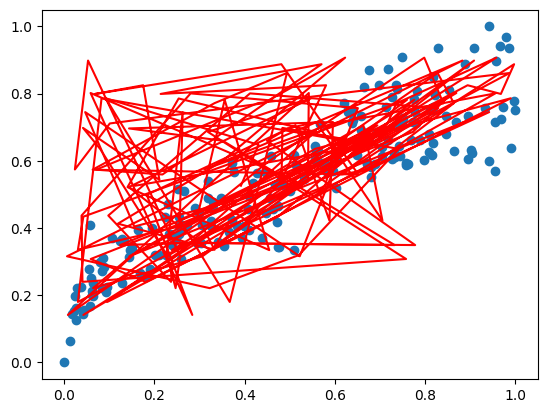

In [39]:
plt.scatter(df['TV'], df['Sales'])
plt.plot(x_test, y_pred,color='red')
plt.show()

In [40]:
import pickle
pickle.dump(slr,open('advertising_sales.pkl','wb'))